# Jupyter Notebook Datamining - WiSe2022/23 - Alexander Mittauer

# Stabilitätsanalyse

# Datenmanipulation - Kopiert aus Haupt-Jupyter-Notebook

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as scn
from sklearn.preprocessing import *
from sklearn.model_selection import *
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import *

data = pd.read_csv("ks-projects-201801.csv")
# Sortieren der Daten nach Launchzeitpunkt
data = data.sort_values("launched")
# Umwandeln des Datentyps zur einfacheren Weiterverarbeitung
data["launched"] = pd.to_datetime(data["launched"])
data["deadline"] = pd.to_datetime(data["deadline"])
# Aufsplitten der Datumsvariablen
data["launched_year"] = data["launched"].dt.year
data["launched_month"] = data["launched"].dt.month
data["launched_day"] = data["launched"].dt.day
data["deadline_year"] = data["deadline"].dt.year
data["deadline_month"] = data["deadline"].dt.month
data["deadline_day"] = data["deadline"].dt.day
# Hinzufügen eines neuen Features (Dauer des Projekts)
data["duration"] = (data["deadline"] - data["launched"]).dt.components["days"]
# DataFrame wird reduziert auf echte Projekte, sodass Platzhalterprojekte verschwinden
data = data.loc[data["launched_year"] > 1970]
# Reduzieren der Daten auf Einträge ab 2017
new = data.loc[data["launched"] >= "2017-01-01 00:00:00"]

# Löschen von unwichtigen Spalten (u.a. werden nicht-Dollarwerte aus Vergleichsgründen nicht mehr betrachtet)
cut = new.drop(["ID", "name", "goal", "pledged", "usd pledged"], axis=1)

# Löschen der zum Aufnahmezeitpunkt aktiven Projekte
relevant = cut[cut.state != 'live']

# Vorbereitung der Daten für Modellgenerierung
analysis = relevant
# Löschen von Einträgen mit State = Canceled oder Suspended
analysis = analysis[analysis.state != "canceled"]
analysis = analysis[analysis.state != "suspended"]
# Umwandeln von nicht stetigen Werten in Integer um sie in Analysen besser verwenden zu können
analysis.state = analysis.state.replace({"successful": 1, "failed": 0})
country_enc = LabelEncoder().fit(analysis["country"])
main_category_enc = LabelEncoder().fit(analysis["main_category"])
category_enc = LabelEncoder().fit(analysis["category"])
currency_enc = LabelEncoder().fit(analysis["currency"])
analysis["country"] = country_enc.transform(analysis["country"])
analysis["main_category"] = main_category_enc.transform(analysis["main_category"])
analysis["category"] = category_enc.transform(analysis["category"])
analysis["currency"] = currency_enc.transform(analysis["currency"])
analysis = analysis.drop(["launched", "deadline"], axis=1)

# Verkleinerung des Datensatzes
analysis = analysis.drop(["currency", "deadline_month"], axis=1)

# Verkleinerung des Datensatzes
analysis2 = analysis
analysis2 = analysis2.drop(["backers", "usd_pledged_real"], axis=1)

# Train/Test-Split Vorbereitung
X2 = analysis2.drop("state", axis=1)
y2 = analysis2["state"]



# Stabilitätsanalyse - Durchführung

C:\Users\alexa\AppData\Local\Temp\ipykernel_13620\2489169645.py:29: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  st_result_pivot = st_result.pivot("randomstate", "category", "accuracy")
C:\Users\alexa\AppData\Local\Temp\ipykernel_13620\2489169645.py:29: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  st_result_pivot = st_result.pivot("randomstate", "category", "accuracy")


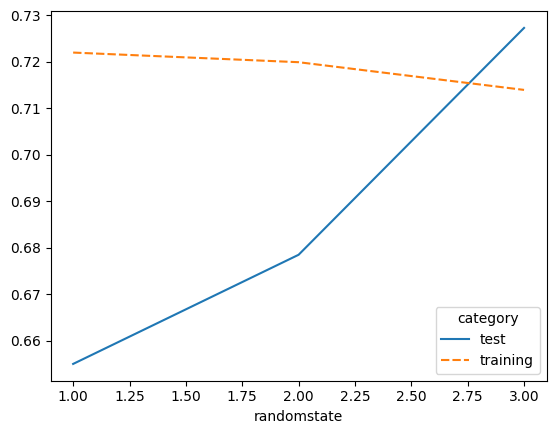

In [2]:
X_train_St_1, X_test_St_1, y_train_St_1, y_test_St_1 = train_test_split(X2,y2, test_size=0.1, random_state=1)
X_train_St_2, X_test_St_2, y_train_St_2, y_test_St_2 = train_test_split(X2,y2, test_size=0.1, random_state=2)
X_train_St_3, X_test_St_3, y_train_St_3, y_test_St_3 = train_test_split(X2,y2, test_size=0.1, random_state=3)

# Modell erstellen 9010
nb_model_St_1 = CategoricalNB()
nb_model_St_1.fit(X_train_St_1, y_train_St_1)
y_pred_train_St_1 = nb_model_St_1.predict(X_train_St_1)
y_pred_test_St_1 = nb_model_St_1.predict(X_test_St_1)
# Modell erstellen 9010
nb_model_St_2 = CategoricalNB()
nb_model_St_2.fit(X_train_St_2, y_train_St_2)
y_pred_train_St_2 = nb_model_St_2.predict(X_train_St_2)
y_pred_test_St_2 = nb_model_St_2.predict(X_test_St_2)
# Modell erstellen 9010
nb_model_St_3 = CategoricalNB()
nb_model_St_3.fit(X_train_St_3, y_train_St_3)
y_pred_train_St_3 = nb_model_St_1.predict(X_train_St_3)
y_pred_test_St_3 = nb_model_St_1.predict(X_test_St_3)

st_result = pd.DataFrame(columns=["randomstate", "accuracy", "category"])
st_result.loc[1] = pd.Series({"randomstate": 1, "accuracy":  accuracy_score(y_test_St_1, y_pred_test_St_1), "category": "test"})
st_result.loc[2] = pd.Series({"randomstate": 1, "accuracy":  accuracy_score(y_train_St_1, y_pred_train_St_1), "category": "training"})
st_result.loc[3] = pd.Series({"randomstate": 2, "accuracy":  accuracy_score(y_test_St_2, y_pred_test_St_2), "category": "test"})
st_result.loc[4] = pd.Series({"randomstate": 2, "accuracy":  accuracy_score(y_train_St_2, y_pred_train_St_2), "category": "training"})
st_result.loc[5] = pd.Series({"randomstate": 3, "accuracy":  accuracy_score(y_test_St_3, y_pred_test_St_3), "category": "test"})
st_result.loc[6] = pd.Series({"randomstate": 3, "accuracy":  accuracy_score(y_train_St_3, y_pred_train_St_3), "category": "training"})

st_result_pivot = st_result.pivot("randomstate", "category", "accuracy")
plt_st_result = scn.lineplot(data=st_result_pivot)

fig_st_result = plt_st_result.get_figure()
fig_st_result.savefig("Stability")



In [3]:
display(st_result)

,randomstate,accuracy,category
1,1,0.654998,test
2,1,0.72201,training
3,2,0.678489,test
4,2,0.719938,training
5,3,0.727315,test
6,3,0.713975,training
